In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Ridge , Lasso 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_rows', None)


In [73]:
df = pd.read_excel("premiums_rest.xlsx")

In [74]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [75]:
df.shape

(29904, 13)

In [76]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


### Checking for NA values

In [77]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handeling NA values

In [78]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [79]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [80]:
print(f"Description of the dataset :")
df.describe()

Description of the dataset :


,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [81]:
df["number_of_dependants"] = abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [82]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

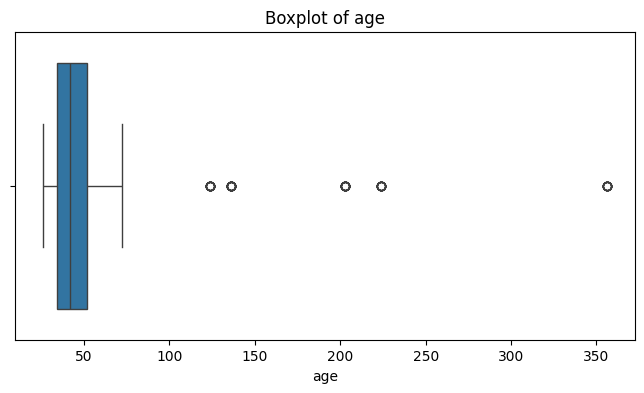

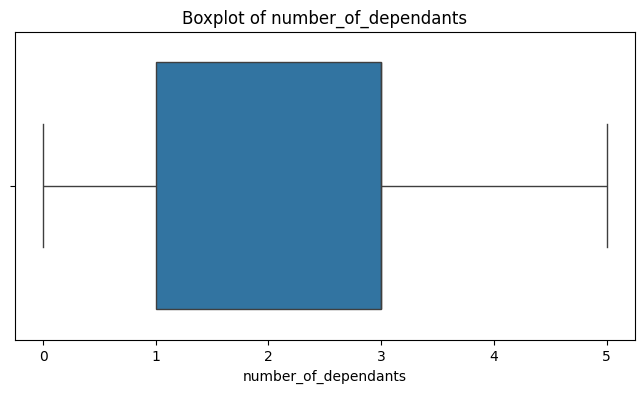

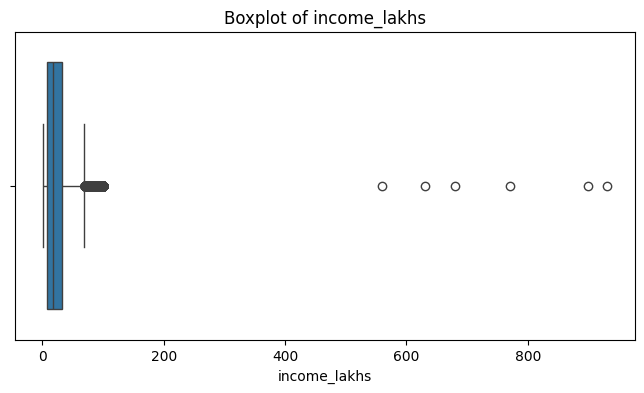

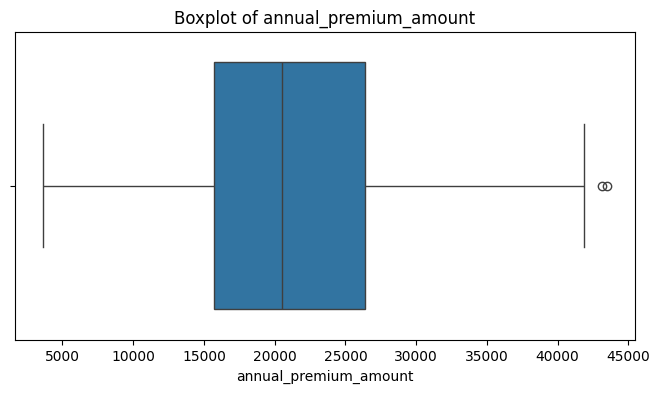

In [83]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Removing outliers of age

In [84]:
df1 = df[df.age<100].copy()

In [85]:
df1.age.describe()

count    29828.000000
mean        43.095380
std         11.041991
min         26.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         72.000000
Name: age, dtype: float64

### An Function for IQR

In [86]:
def get_iqr_bounds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [87]:
get_iqr_bounds(df1['income_lakhs'])

(np.float64(-30.5), np.float64(69.5))

In [88]:
quantile_threshold = df1['income_lakhs'].quantile(0.999)
quantile_threshold

np.float64(100.0)

In [89]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29822.000000,29822.000000,29822.000000,29822.000000
mean,43.094896,2.387734,23.226343,20900.689223
std,11.042430,1.420644,22.455408,6928.192115
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15705.250000
50%,42.000000,3.000000,17.000000,20495.500000
75%,52.000000,3.000000,32.000000,26360.000000
max,72.000000,5.000000,100.000000,43471.000000


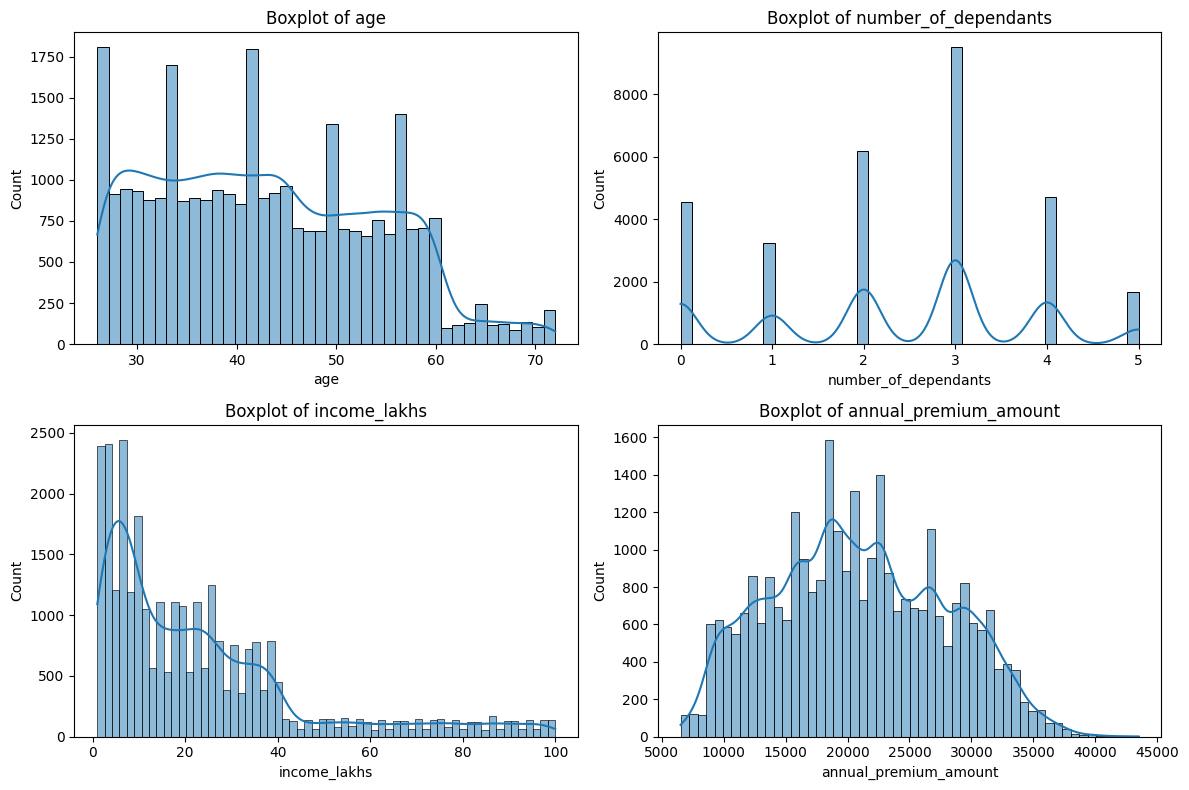

In [90]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for i,column in enumerate(numeric_columns):
    ax = axes[i // 2, i % 2]
    sns.histplot(x=df2[column], ax=ax, kde=True)
    ax.set_title(f'Boxplot of {column}')
    
plt.tight_layout()
plt.show()

<Axes: xlabel='age', ylabel='annual_premium_amount'>

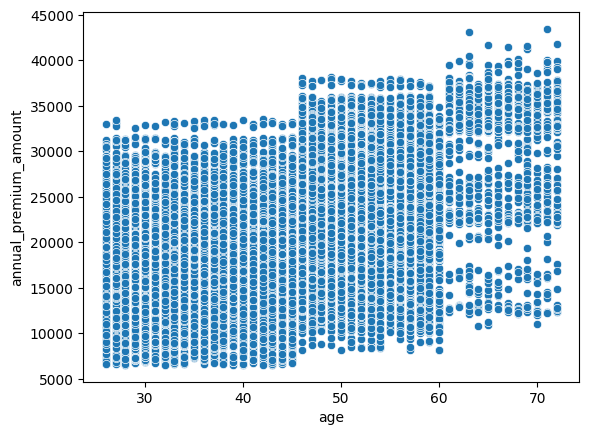

In [91]:
sns.scatterplot(data=df2, x='age', y='annual_premium_amount')

In [92]:
categorical_columns = df2.select_dtypes(include=['object']).columns

C:\Users\ittis\AppData\Local\Temp\ipykernel_21808\1042019130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df2.select_dtypes(include=['object']).columns


In [93]:
for col in categorical_columns:
    print(f"{col} : {df2[col].unique().tolist()}")

gender : ['Male', 'Female']
region : ['Northwest', 'Southeast', 'Northeast', 'Southwest']
marital_status : ['Unmarried', 'Married']
bmi_category : ['Normal', 'Obesity', 'Overweight', 'Underweight']
smoking_status : ['No Smoking', 'Regular', 'Occasional', 'Does Not Smoke', 'Not Smoking', 'Smoking=0']
employment_status : ['Salaried', 'Self-Employed', 'Freelancer']
income_level : ['<10L', '10L - 25L', '> 40L', '25L - 40L']
medical_history : ['Diabetes', 'High blood pressure', 'No Disease', 'Diabetes & High blood pressure', 'Thyroid', 'Heart disease', 'High blood pressure & Heart disease', 'Diabetes & Thyroid', 'Diabetes & Heart disease']
insurance_plan : ['Bronze', 'Silver', 'Gold']


In [94]:
df2.replace({
    'Not Smoking': 'No Smoking',
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke' : 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

<ArrowStringArray>
['No Smoking', 'Regular', 'Occasional']
Length: 3, dtype: str

In [95]:
pct_count = df2['gender'].value_counts(normalize=True)
pct_count

gender
Male      0.549125
Female    0.450875
Name: proportion, dtype: float64

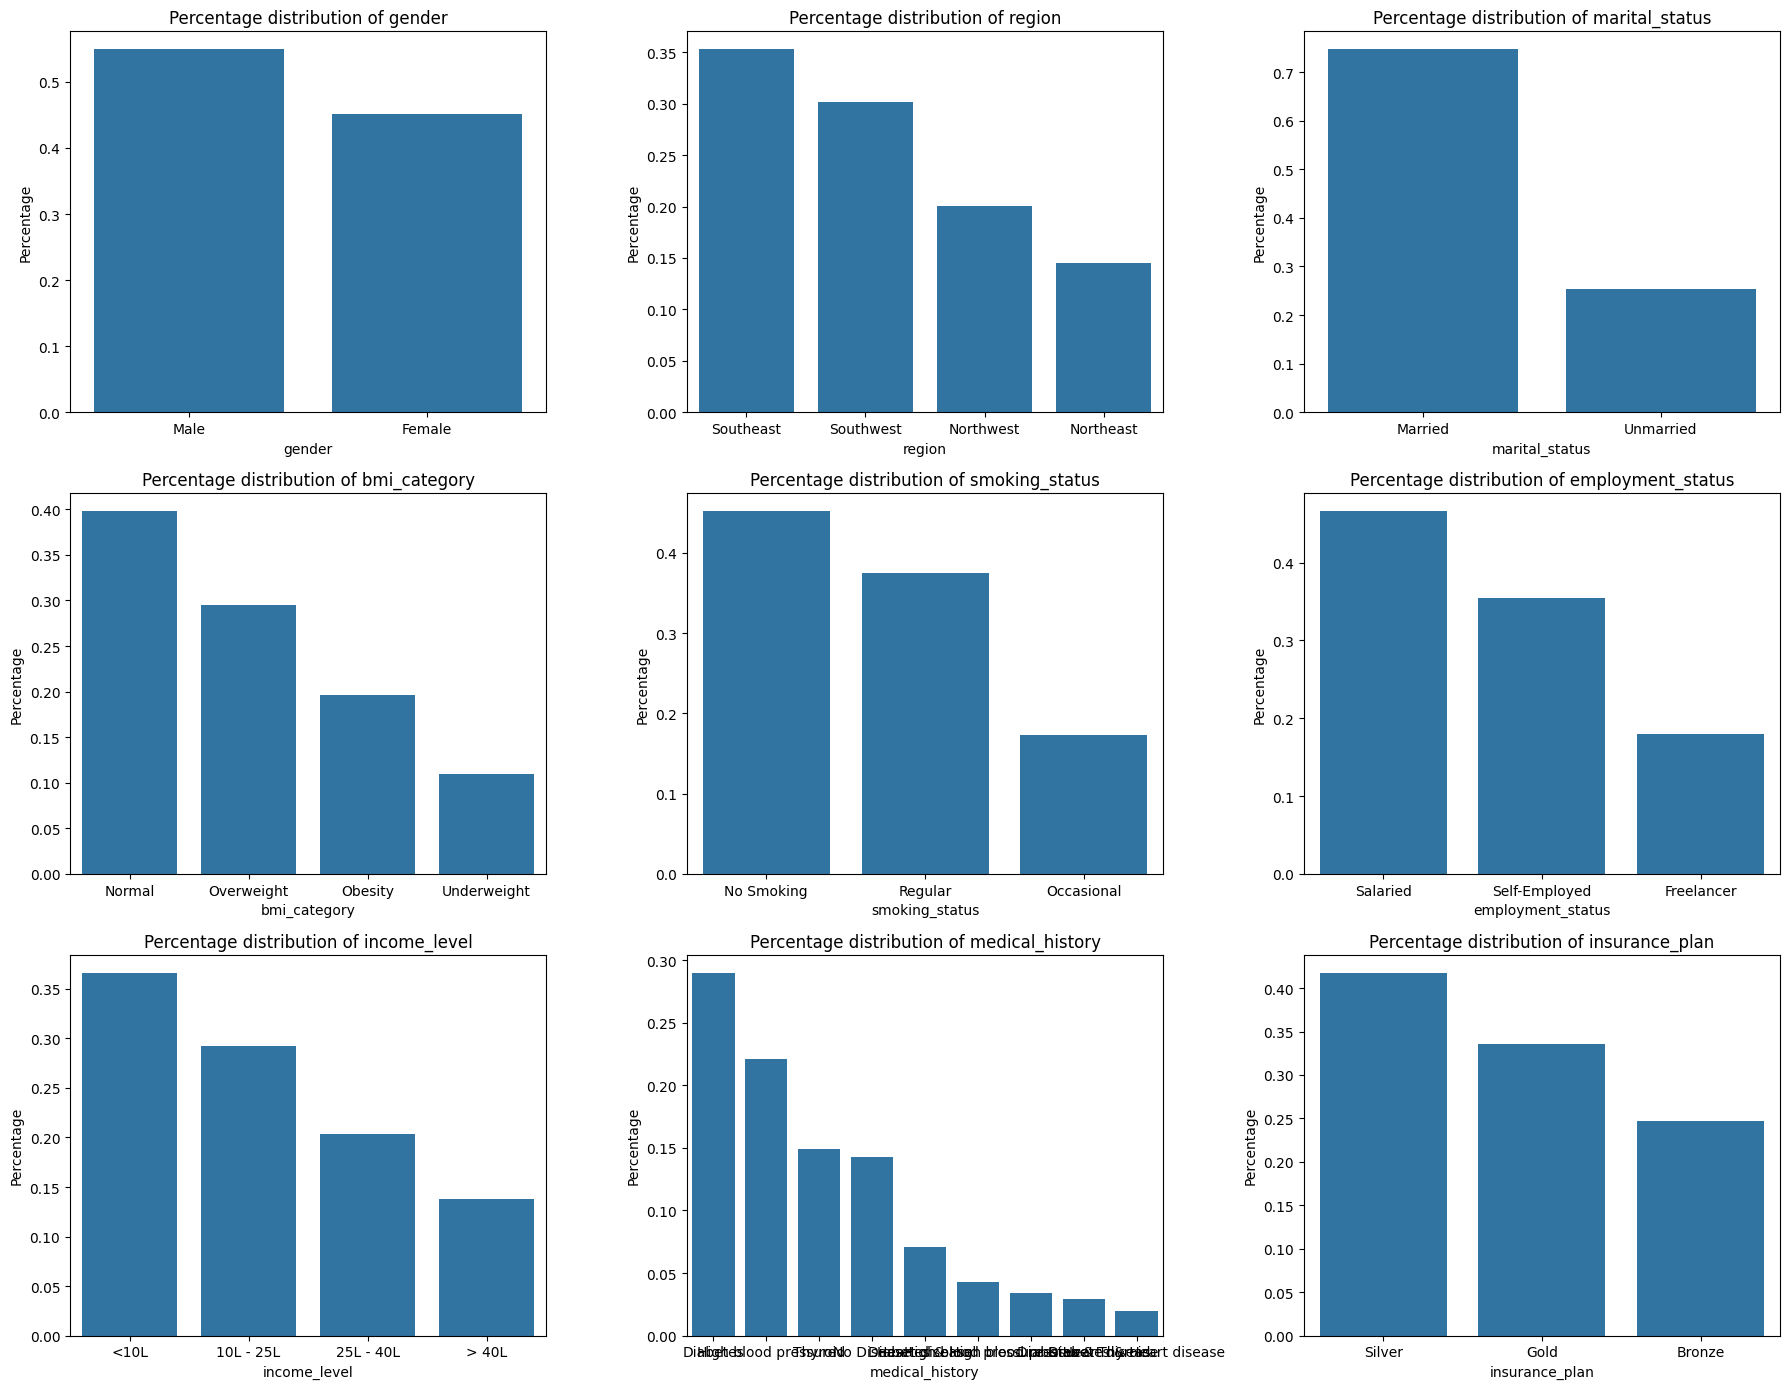

In [96]:
fig, axes = plt.subplots(3,3,figsize=(18, 14))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    category_counts = df2[column].value_counts(normalize=True)
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Percentage')
    
plt.tight_layout()
plt.show()

In [97]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,799,3554,4354
25L - 40L,301,2631,3142
<10L,6054,527,4341
> 40L,214,3287,618


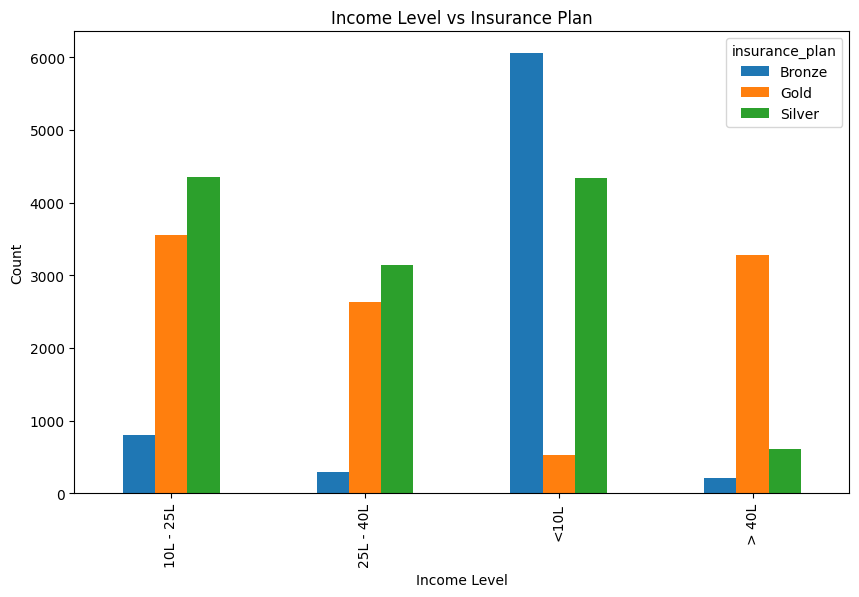

In [98]:
crosstab.plot(kind='bar', figsize=(10, 6))
plt.title('Income Level vs Insurance Plan')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

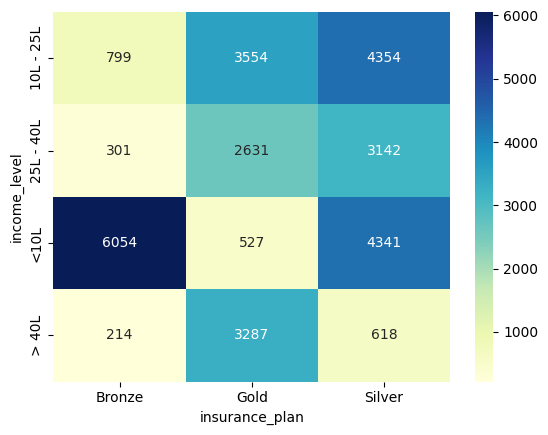

In [99]:
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')

In [100]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [101]:
df2.medical_history.unique()

<ArrowStringArray>
[                           'Diabetes',                 'High blood pressure',
                          'No Disease',      'Diabetes & High blood pressure',
                             'Thyroid',                       'Heart disease',
 'High blood pressure & Heart disease',                  'Diabetes & Thyroid',
            'Diabetes & Heart disease']
Length: 9, dtype: str

In [102]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1','disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x : x.str.lower())

In [103]:
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')

df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += (
        df2[disease]
        .map(risk_scores)
        .fillna(0)
    )

min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalized_risk_score'] = (
    df2['total_risk_score'] - min_score
) / (max_score - min_score)

df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,none,6,0.428571


###  Encoding the Categorical columns

In [104]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [105]:
df2.income_level.unique()

<ArrowStringArray>
['<10L', '10L - 25L', '> 40L', '25L - 40L']
Length: 4, dtype: str

In [106]:

df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [107]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1


In [108]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)                

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


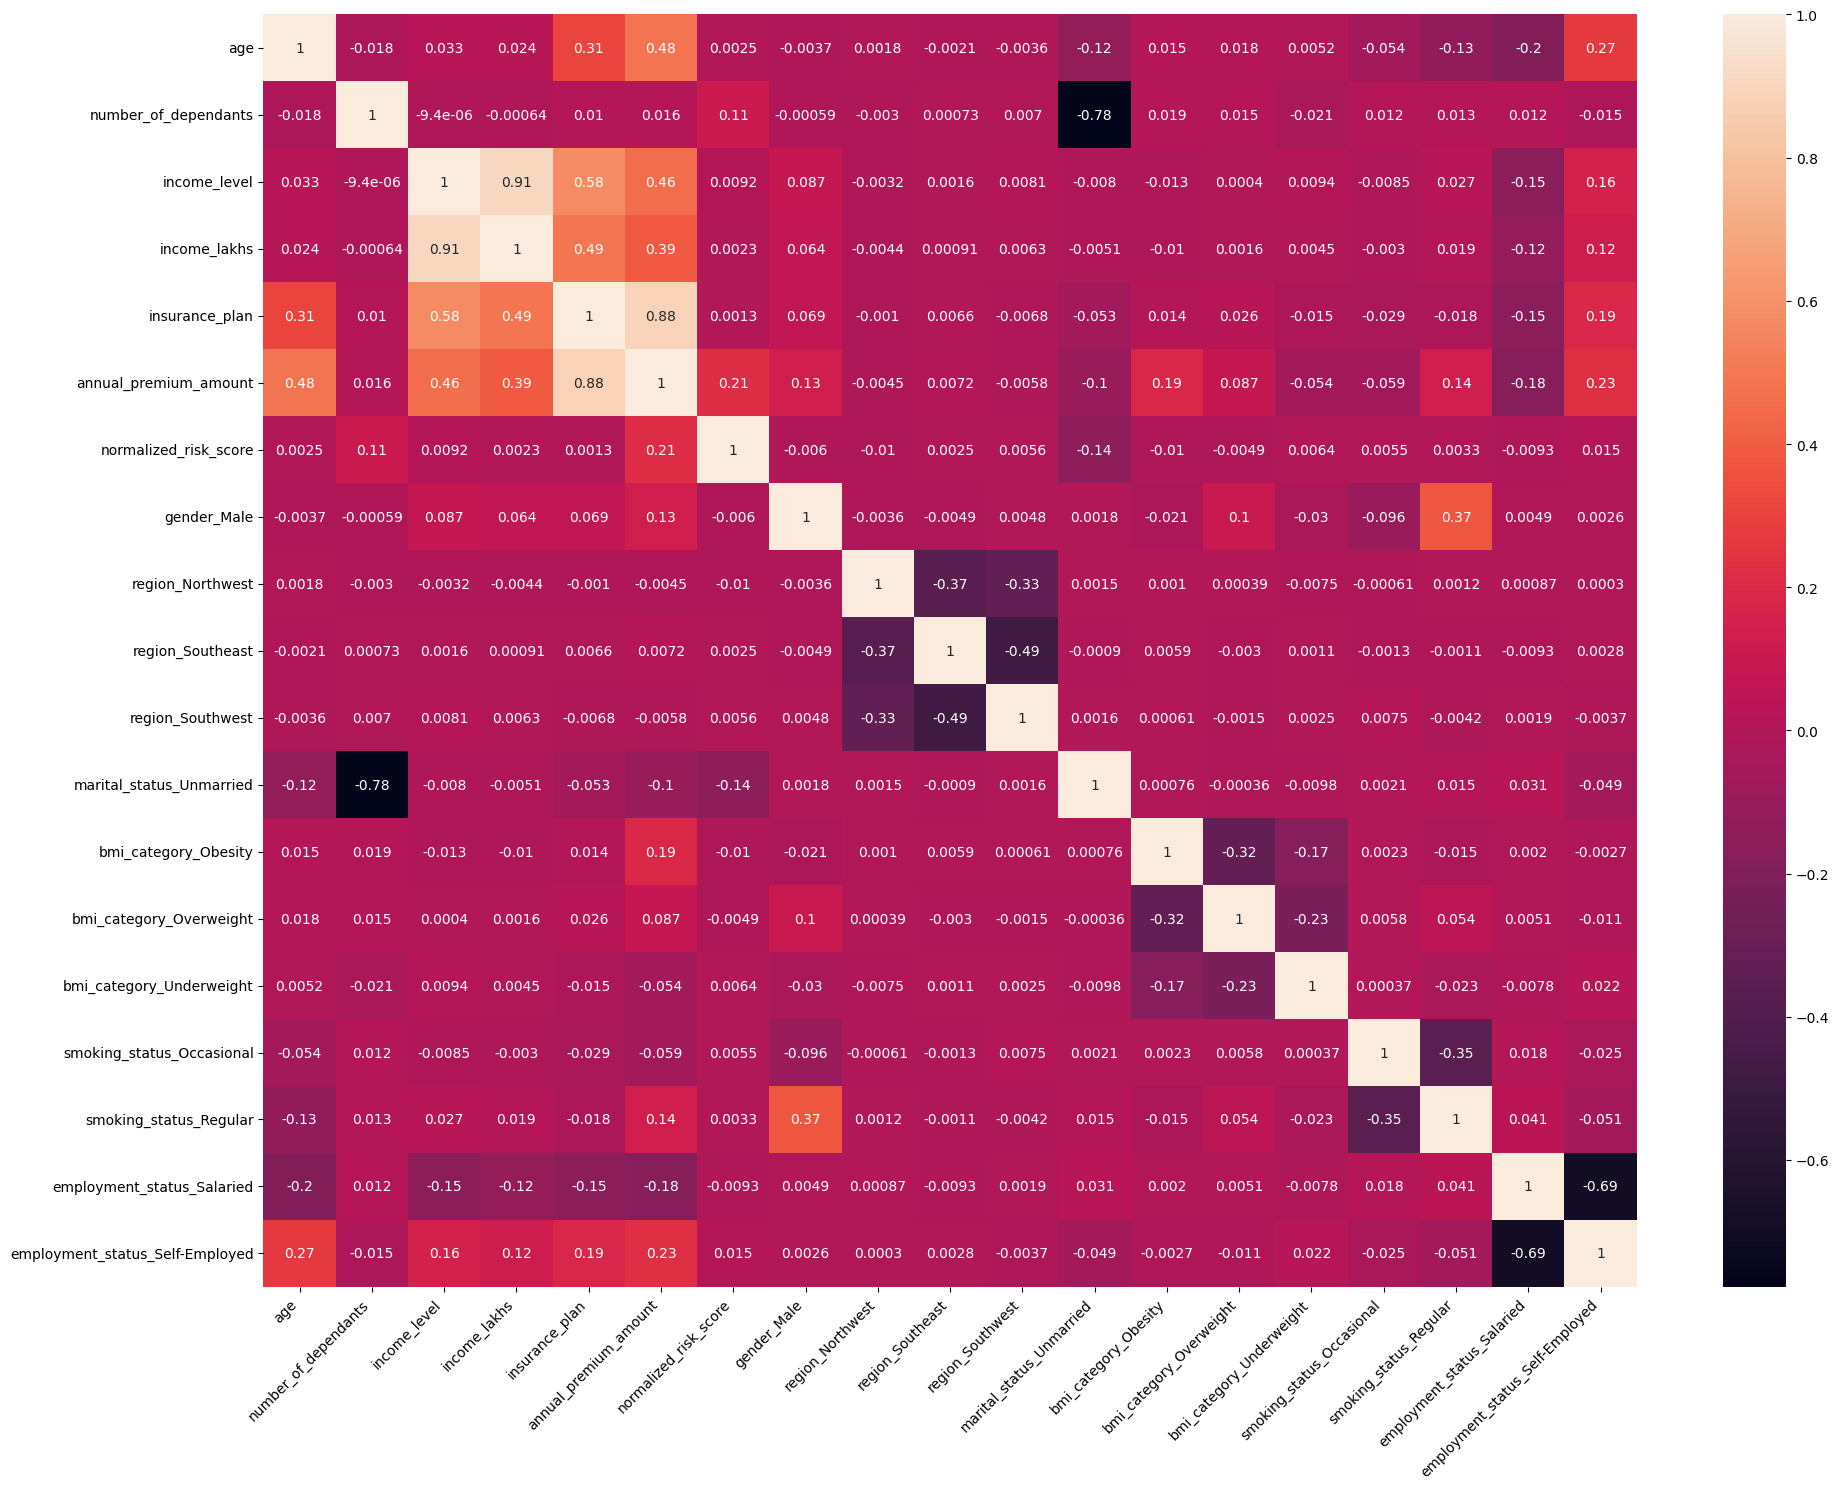

In [109]:
cm = df4.corr()

plt.figure(figsize=(20,15))
sns.heatmap(cm, annot=True)
plt.xticks(rotation = 45 , ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()


 <h2 align="center" style="color:Yellow">Feature Engineering</h2>

In [110]:
df4.head(7)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0.428571,1,0,0,0,0,1,0,0,1,0,0,1
5,33,3,1,4,2,20653,0.857143,1,0,1,0,0,0,0,0,0,1,0,1
6,43,3,4,46,3,26926,0.357143,1,0,0,0,0,0,1,0,0,1,1,0


In [111]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [113]:
calculate_vif(X)

,Column,VIF
0,age,1.294096
1,number_of_dependants,2.629940
2,income_level,6.560804
3,income_lakhs,5.654229
4,insurance_plan,1.732282
5,normalized_risk_score,1.021439
6,gender_Male,1.185501
7,region_Northwest,1.909338
8,region_Southeast,2.227294
9,region_Southwest,2.157461


In [114]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,1.274986
1,number_of_dependants,2.629927
2,income_lakhs,1.363209
3,insurance_plan,1.506512
4,normalized_risk_score,1.021131
5,gender_Male,1.182292
6,region_Northwest,1.909110
7,region_Southeast,2.227075
8,region_Southwest,2.156953
9,marital_status_Unmarried,2.690030


In [115]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:Yellow">Model Training</h2>

In [116]:
X_train , X_test , y_train , y_test = train_test_split(X_reduced, y , test_size= 0.25, random_state=20)
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (22366, 17)
x test:  (7456, 17)
y train:  (22366,)
y test:  (7456,)


In [117]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
model_lr.score(X_test,y_test)


0.9537112746338529

In [118]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  2200126.113670234 RMSE:  1483.2822097194567


In [119]:
feature_importance = model_lr.coef_

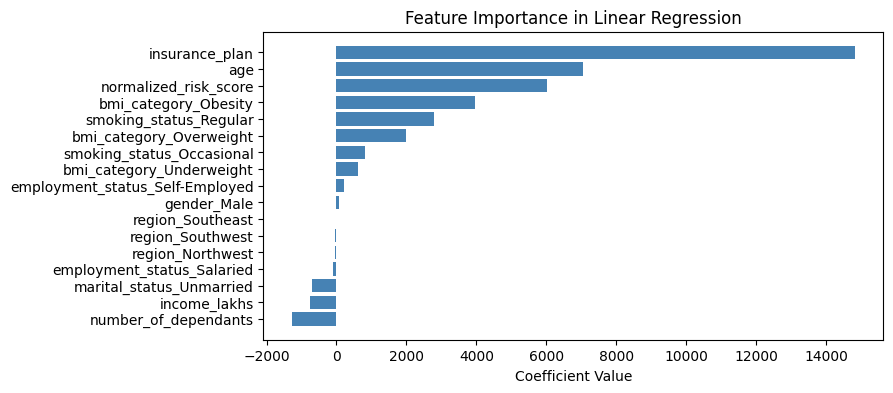

In [120]:

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])


coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

<h2 align="center" style="color:Yellow">Ridge Regression Model</h2>

In [121]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9534879385643171, 0.9537127261894184)

In [122]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  2200057.120513048 RMSE:  1483.258952615169


<h2 align="center" style="color:Yellow">XGBOOST Regression Model</h2>

In [123]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9948216676712036

In [124]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  246128.75 RMSE:  496.11364625456537


In [125]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9969777862230936)

In [126]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [127]:
best_model = random_search.best_estimator_

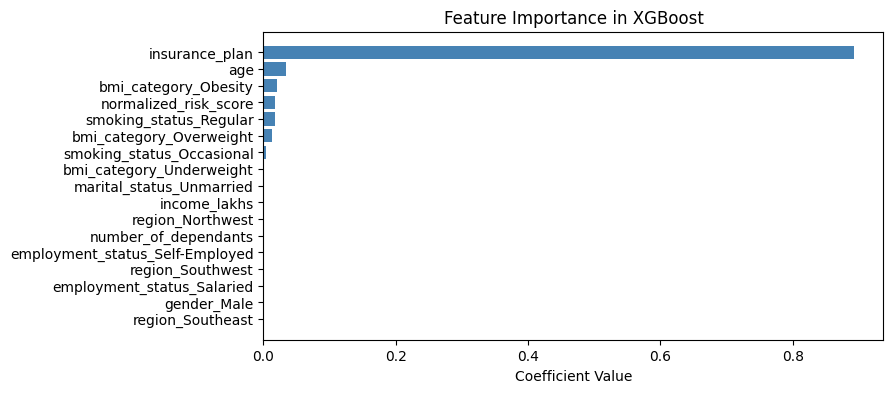

In [128]:
feature_importance = best_model.feature_importances_


coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

<h2 align="center" style="color:Yellow">Error Calculation</h2>

In [129]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
25084,9921,9702.551758,-218.448242,-2.201877
15145,15648,16034.353516,386.353516,2.469028
12855,17338,17626.349609,288.349609,1.663108
29581,20520,20650.404297,130.404297,0.635499
11568,24406,24065.449219,-340.550781,-1.395357


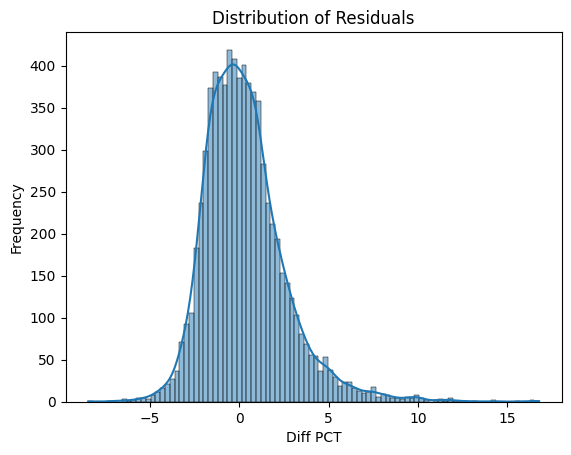

In [130]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [131]:
extreme_error_threshold = 10

extreme_results_df = results_df[np.abs(results_df.diff_pct)> extreme_error_threshold] 
extreme_results_df.shape

(27, 4)

In [132]:
extreme_results_df.shape[0]*100/results_df.shape[0]

0.3621244635193133

In [133]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct


In [134]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
28595,0.217391,0.0,0.303030,0.0,0.000000,0,0,0,1,1,0,0,0,1,0,0,1
22666,0.369565,0.0,0.060606,0.0,0.000000,0,0,0,1,1,0,0,0,0,0,0,0
26591,0.739130,0.6,0.212121,0.0,0.000000,1,0,1,0,0,0,0,0,0,0,0,1
11231,0.413043,0.6,0.050505,0.0,0.000000,1,0,0,0,0,0,0,0,0,0,1,0
14286,0.021739,0.6,0.050505,0.0,0.000000,1,1,0,0,1,0,0,0,0,0,1,0
14728,0.413043,0.0,0.060606,0.0,0.000000,1,1,0,0,1,0,0,0,0,0,0,1
25440,0.260870,0.6,0.050505,0.0,0.000000,0,0,0,1,0,0,0,0,0,0,0,0
10971,0.239130,0.2,0.060606,0.0,0.428571,0,1,0,0,1,0,0,0,0,0,1,0
4557,0.521739,0.6,0.171717,0.0,0.000000,1,0,0,1,0,0,0,0,0,0,0,0
6163,0.217391,0.0,0.000000,0.0,0.000000,0,0,0,1,1,0,0,0,0,0,0,0


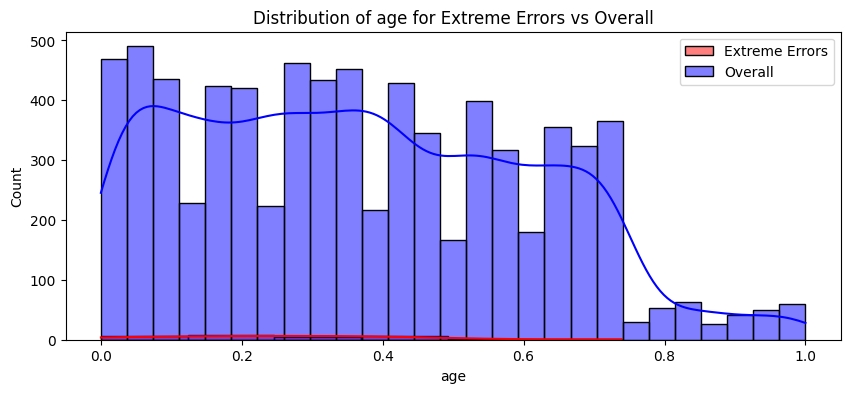

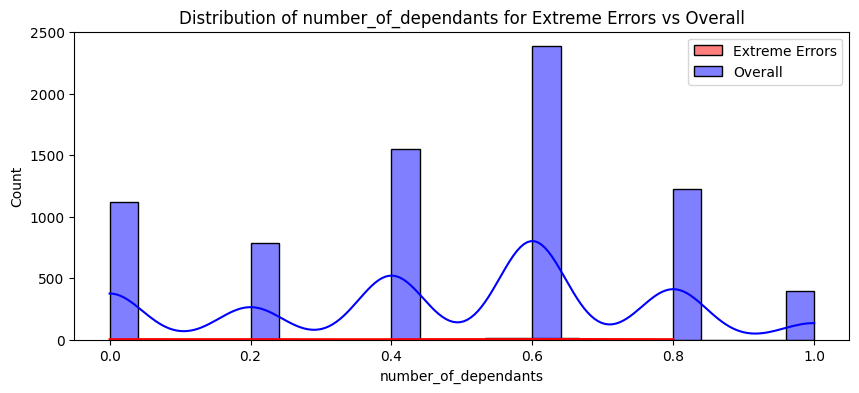

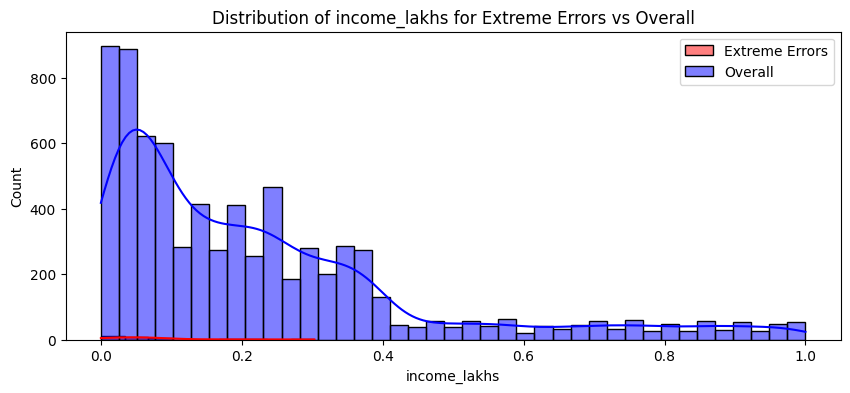

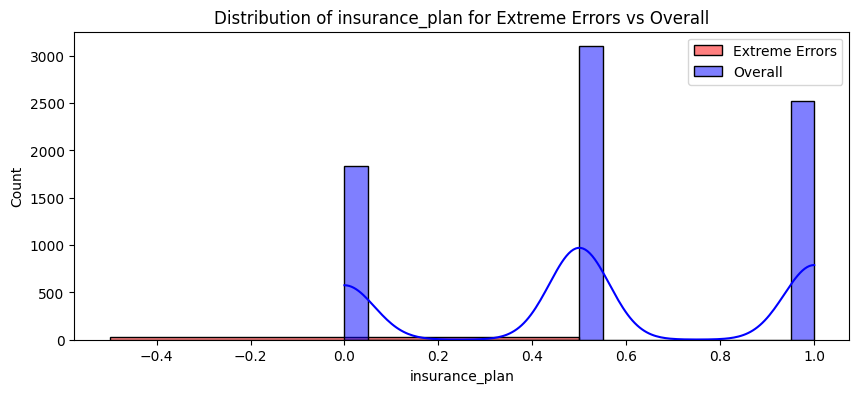

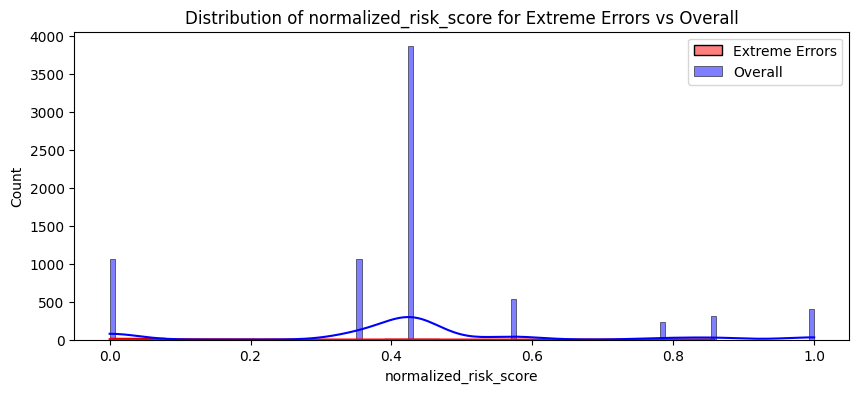

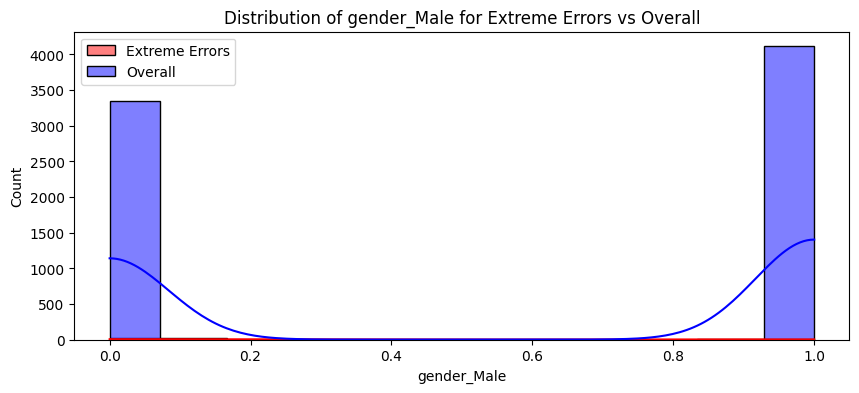

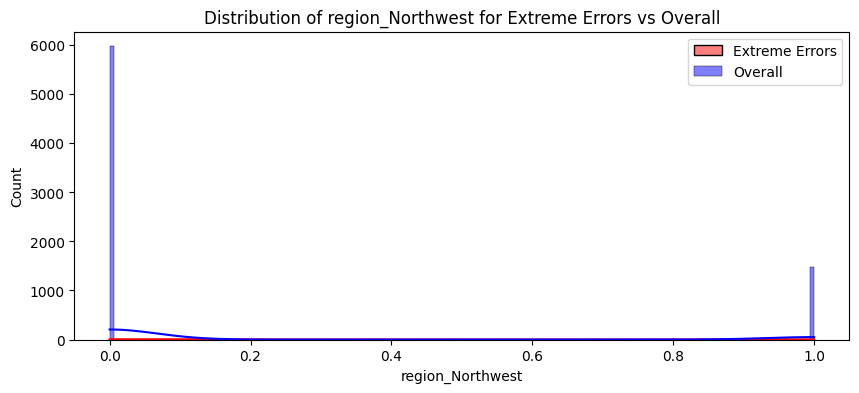

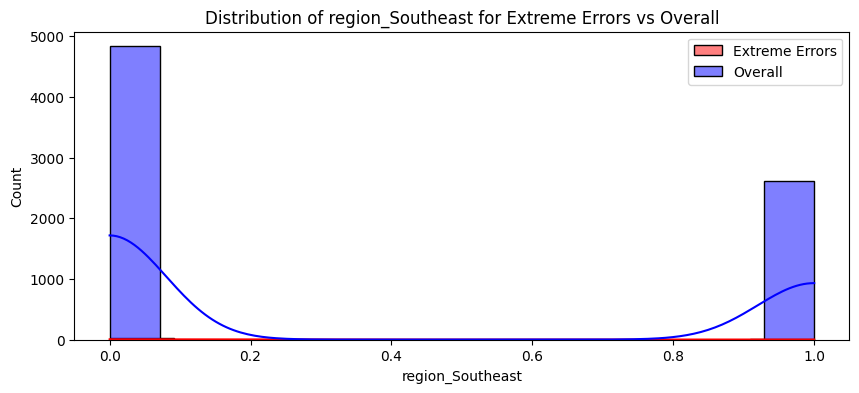

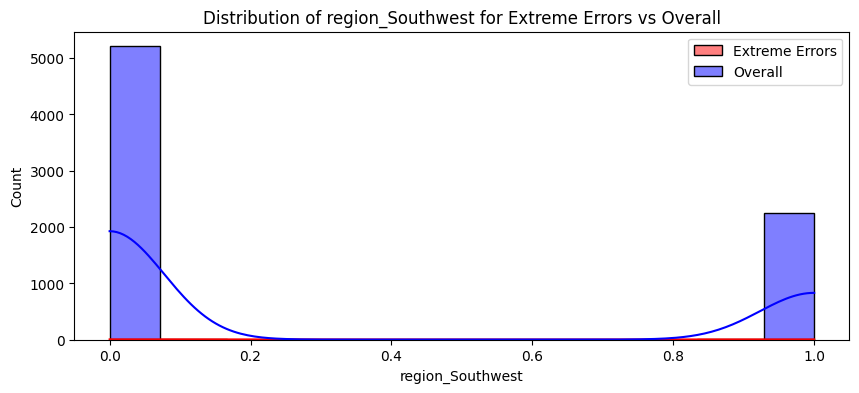

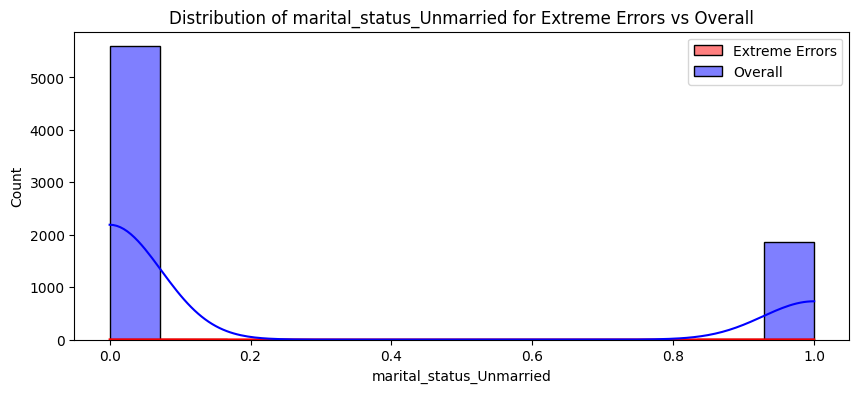

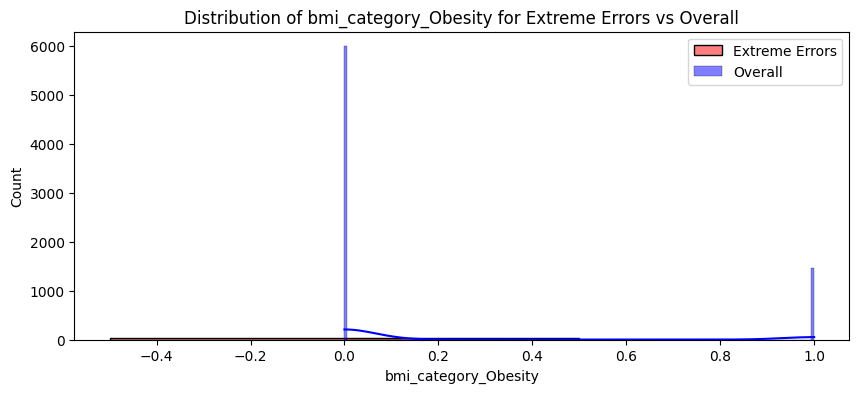

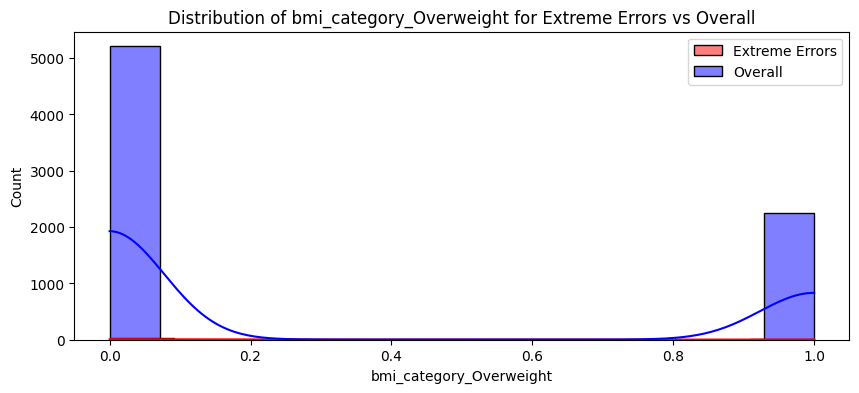

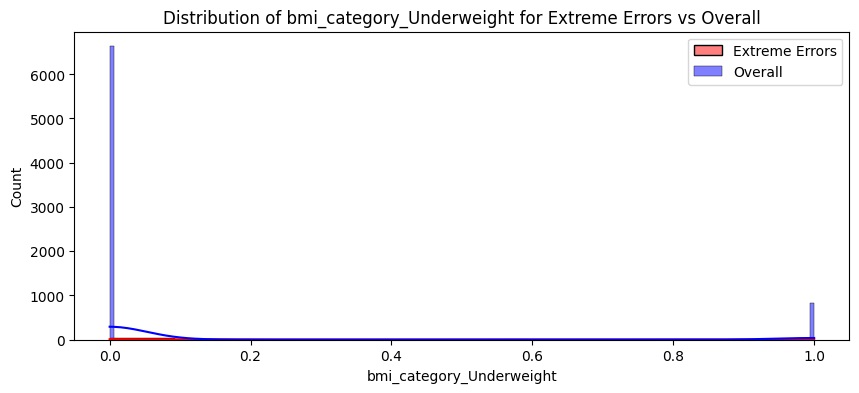

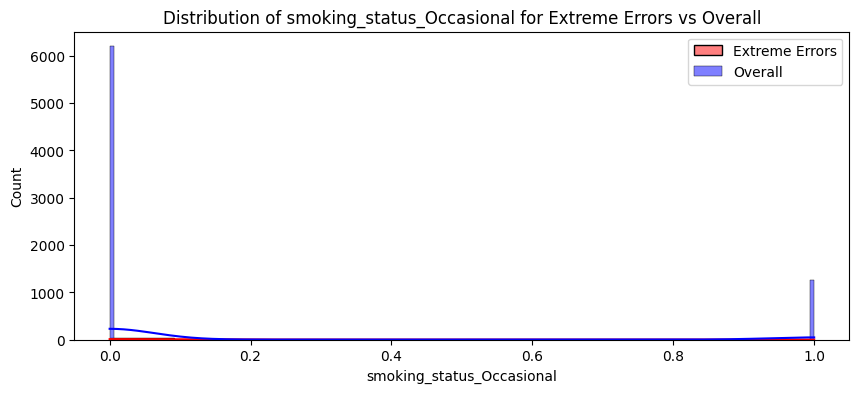

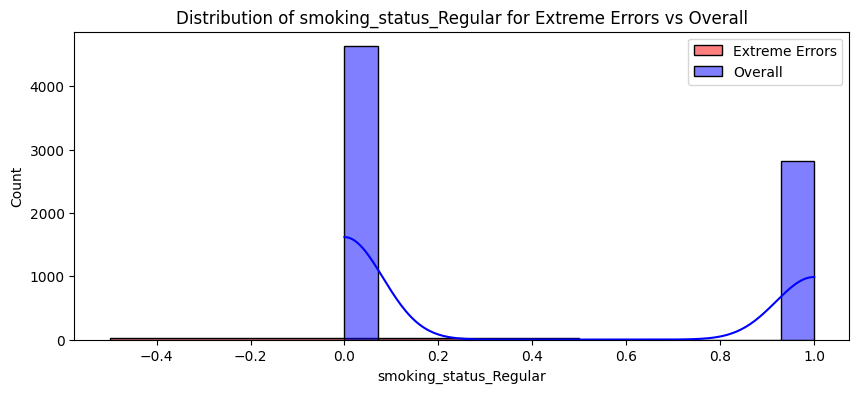

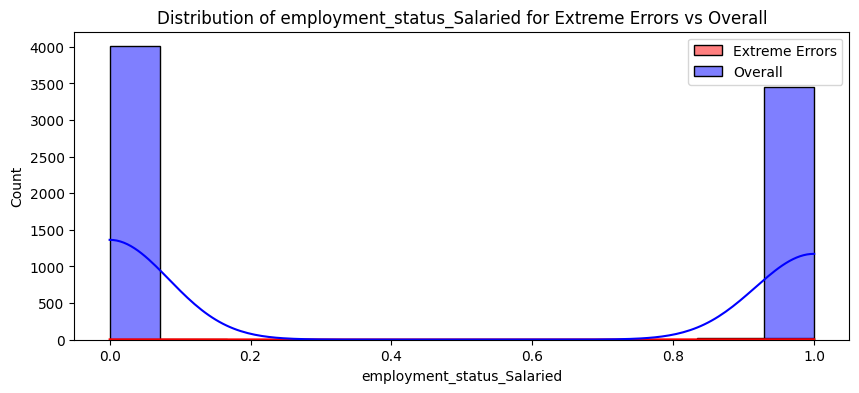

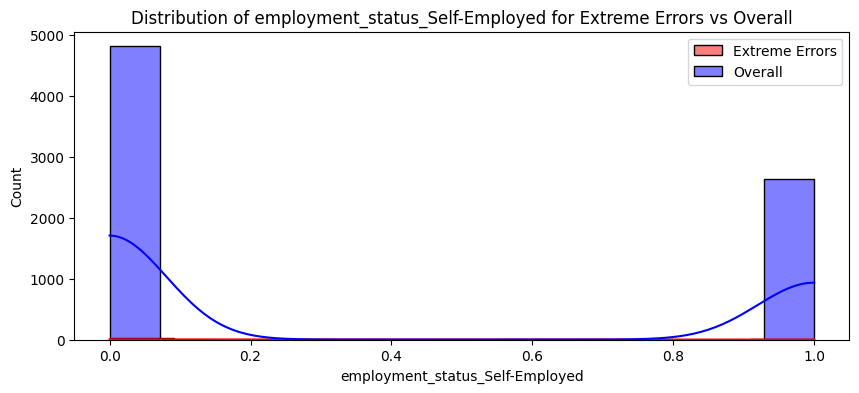

In [135]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

# reverse scaling

In [136]:
extreme_errors_df['income_level']=-1

In [137]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,36.0,0.0,-2.0,31.0,1.0
1,43.0,0.0,-2.0,7.0,1.0
2,60.0,3.0,-2.0,22.0,1.0
3,45.0,3.0,-2.0,6.0,1.0
4,27.0,3.0,-2.0,6.0,1.0


In [138]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,27.000000,27.000000,27.0,27.000000,27.0
mean,37.666667,1.962963,-2.0,7.259259,1.0
std,8.227534,1.453946,0.0,6.751596,0.0
min,26.000000,0.000000,-2.0,1.000000,1.0
25%,32.000000,0.500000,-2.0,3.500000,1.0
50%,37.000000,3.000000,-2.0,6.000000,1.0
75%,44.000000,3.000000,-2.0,9.000000,1.0
max,60.000000,4.000000,-2.0,31.000000,1.0


<Axes: xlabel='age', ylabel='Count'>

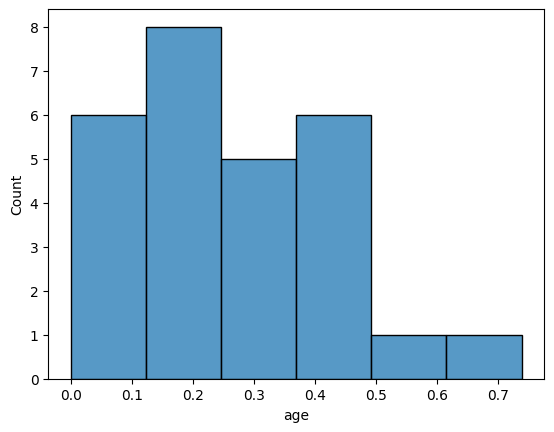

In [139]:
sns.histplot(extreme_errors_df.age)

<Axes: xlabel='age', ylabel='Count'>

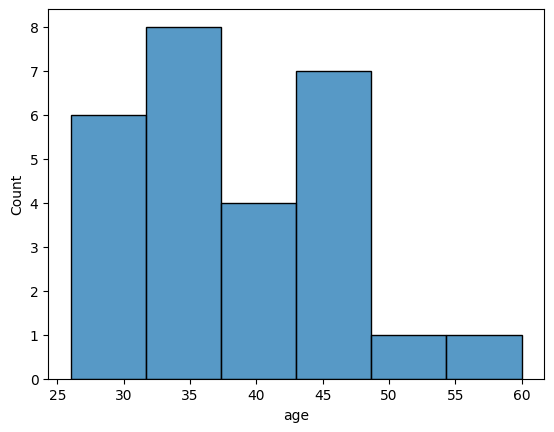

In [140]:
sns.histplot(df_reversed.age)